# Using quspin to try and understand $<k|O|0>$

In [2]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
timestamp = time()
sys.path.append("../../src")
from common_imports import *

In [3]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list

In [4]:
###### Model parameters
#Length of chain
L = 10
#X fields
J1 = 1 #NN term 
h0 = 0
#Basis being projected
op = "x"

In [5]:
###Using Quantum_Operator to build hamitlonian 
timestamp = time()
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
#site coupling lists
sigma_z = [ [1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
##########################################################################################
basis = spin_basis_1d(L,pblock=1)
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False);
#Define Parameters########################################################################
params_dict = dict( H0=1, Quench=0)
#Build H0
H0 = H.tohamiltonian(params_dict)
#Find eigenvalues
E1,V1 = np.linalg.eigh(H0.todense())
V1 = np.array(V1)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5361/944089419.py:16: RuntimeWarning: divide by zero encountered in matmul
  dat.append(np.vdot(U0,P0@Ui))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5361/944089419.py:16: RuntimeWarning: overflow encountered in matmul
  dat.append(np.vdot(U0,P0@Ui))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_5361/944089419.py:16: RuntimeWarning: invalid value encountered in matmul
  dat.append(np.vdot(U0,P0@Ui))


(0.3, 0.7)

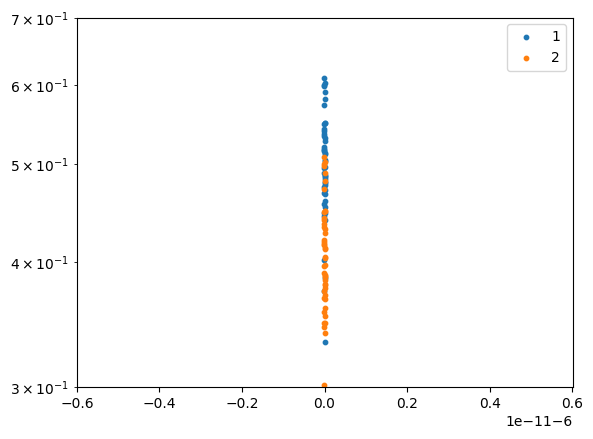

In [26]:
def Pn(n):
    return array(fin_string(n,op)[0].todense())

def exp(op,state):
    return np.vdot(state,op@state)
n=1
x= 0
for n in range(1,3):
    P0 = Pn(n)
    dat=[]
    x = []
    for i in range(2,51):
        j = i
        U0 = V1[:,j]
        Ui = V1[:,i]
        dat.append(np.vdot(U0,P0@Ui))
        x.append(E1[i])
    scatter(x,dat,label=f"{n}",s=10)

legend()
yscale("log")
ylim(0.3,.7)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: x and y must be the same size

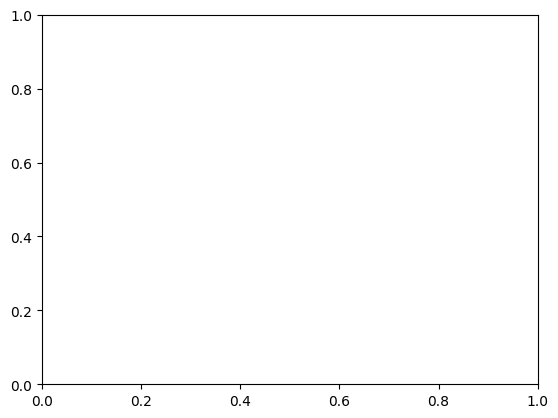

In [29]:
scatter([1],dat)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/3318764513.py:6: RuntimeWarning: divide by zero encountered in matmul
  val= U0.T@P0@U0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/3318764513.py:6: RuntimeWarning: overflow encountered in matmul
  val= U0.T@P0@U0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/3318764513.py:6: RuntimeWarning: invalid value encountered in matmul
  val= U0.T@P0@U0
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: x and y can be no greater than 2D, but have shapes (224,) and (224, 1, 1)

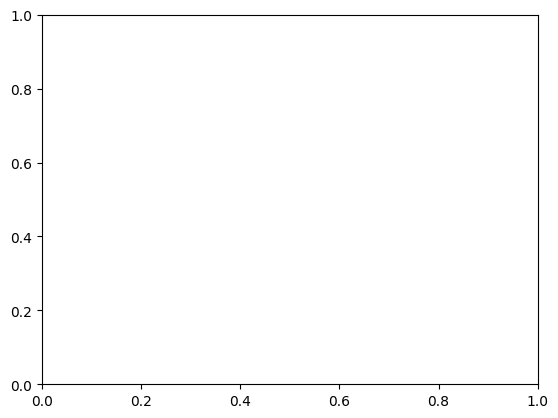

In [212]:
dat= []
P0 = array(fin_string(L-3,op)[0].todense())

for i in range(len(E1)):
    U0 = V1[:,i]
    val= U0.T@P0@U0
    dat+=[val]

dat=array(dat)


plot(dat)

In [87]:
import numpy as np
from quspin.basis import spin_basis_1d
from quspin.operators import quantum_operator
dat=[]
L = 12
for k in range(L):

    J1 = 1.0
   # k = 1 # example momentum sector index for L sites

    # full basis (no symmetry blocks) → use for operators and inner products
    basis = spin_basis_1d(L, pauli=-1)

    # define your operators once in the full basis
    NN_sigma_x = [[-J1, i, (i+1)%L] for i in range(L)]
    sigma_z    = [[1.0, i] for i in range(L)]
    static_H   = [["xx", NN_sigma_x]]
    Quench_H   = [["z", sigma_z]]
    op_dict    = dict(H0=static_H, Quench=Quench_H)

    H_full = quantum_operator(op_dict, basis=basis, check_herm=False, check_symm=False)
    params  = dict(H0=1.0, Quench=0.0)

    # build your projector P in the full basis (example below; replace with yours)
    # example: projector onto all-+x on sites [0..n-1] (here just placeholder diagonal)
    # P_full should be a (Ns x Ns) matrix or LinearOperator in basis_full ordering
    P_full = np.array(fin_string(5,op)[0].todense()) # <-- replace with your actual P

    # helper: embed a vector from a symmetry block into the full basis
    def embed(vec_sub, basis_sub, basis_full):
        out = np.zeros(basis_full.Ns, dtype=complex)
        for i, state in enumerate(basis_sub.states):
            j = basis_full.index(state)
            out[j] = vec_sub[i]
        return out

    # ground state from k=0 block
    basis_k0 = spin_basis_1d(L, pauli=-1, kblock=0)
    H_k0 = quantum_operator(op_dict, basis=basis_k0, check_herm=False, check_symm=False).tohamiltonian(params)
    E0, V0 = np.linalg.eigh(H_k0.todense())
    psi0_full = embed(V0[:,0], basis_k0, basis)   # |0> in full basis

    # one-quasiparticle momentum-k state from k-block
    basis_k = spin_basis_1d(L, pauli=-1, kblock=k)
    H_k = quantum_operator(op_dict, basis=basis_k, check_herm=False, check_symm=False).tohamiltonian(params)
    Ek, Vk = np.linalg.eigh(H_k.todense())
    psik_full = embed(Vk[:,0], basis_k, basis)    # |k> in full basis

    # normalize (should already be, but cheap)
    psi0_full /= np.linalg.norm(psi0_full)
    psik_full /= np.linalg.norm(psik_full)

    # compute <0|P|k>
    val = np.vdot(psi0_full, P_full @ psik_full)
    print(val)
    dat.append(val)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/1813816982.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  out[j] = vec_sub[i]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/1813816982.py:54: RuntimeWarning: divide by zero encountered in matmul
  val = np.vdot(psi0_full, P_full @ psik_full)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/1813816982.py:54: RuntimeWarning: overflow encountered in matmul
  val = np.vdot(psi0_full, P_full @ psik_full)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_4188/1813816982.py:54: RuntimeWarning: invalid value encountered in matmul
  val = np.vdot(psi0_full, P_full @ psik_full)


(0.21772140756411207+0j)
(0.012230555221472629+0.02556039649726511j)
(0.017617736178119636-6.972384077740416e-05j)
(-0.004522327895227413+0.0006318332231112715j)
(0.013684461841921436-0.00729353302887878j)
(0.08179729448159426-0.017797747226356544j)
(0.029110254502335713-0.09488272712097276j)
(0.10106506115090663+0.016664651535891094j)
(-0.11018936739486629+0.04387271064585469j)
(0.10006358234526934+0.020662629755316873j)
(0.01371965438580561-0.004018510272156554j)
(0.04047497645498917-0.16771983569248985j)


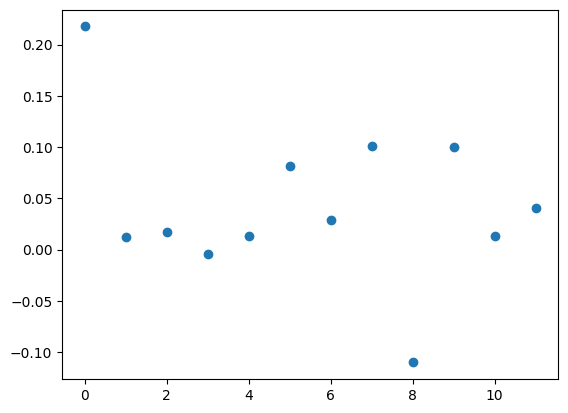

In [88]:
scatter([i for i in range(L)],dat)

In [122]:
import numpy as np

L = 4

# enumerate full x-basis as strings of '+'/'-'
def cfg_from_int(x):
    return ''.join('+' if (x>>(L-1-i))&1 else '-' for i in range(L))
basis = [cfg_from_int(x) for x in range(1<<L)]
idx   = {s:i for i,s in enumerate(basis)}

def ket(s):
    v = np.zeros(len(basis), complex); v[idx[s]] = 1.0; return v

# ground state |++++>
psi0 = ket('++++')

# two-domain-wall superposition (PBC): ++--, --++, +--+, -++-
two_walls = ['++--','--++','+--+','-++-']
psi_pair = sum(ket(s) for s in two_walls); psi_pair /= np.linalg.norm(psi_pair)

# partial projector on first 2 spins being +x: P2 = sum_{tails R} |++R><++R|
P2 = np.zeros((len(basis),len(basis)), complex)
for s in basis:
    if s[:2] == '++':
        P2[idx[s], idx[s]] = 1.0

val = np.vdot(psi0, P2 @ psi_pair)
print(val)  # -> 0.0


0j


In [124]:
psi_pair

array([0. +0.j, 0. +0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j,
       0. +0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j, 0. +0.j,
       0. +0.j, 0. +0.j])

In [125]:
len(psi_pair)

16

In [127]:
2**4

16